# Comparacion normal vs mejorado

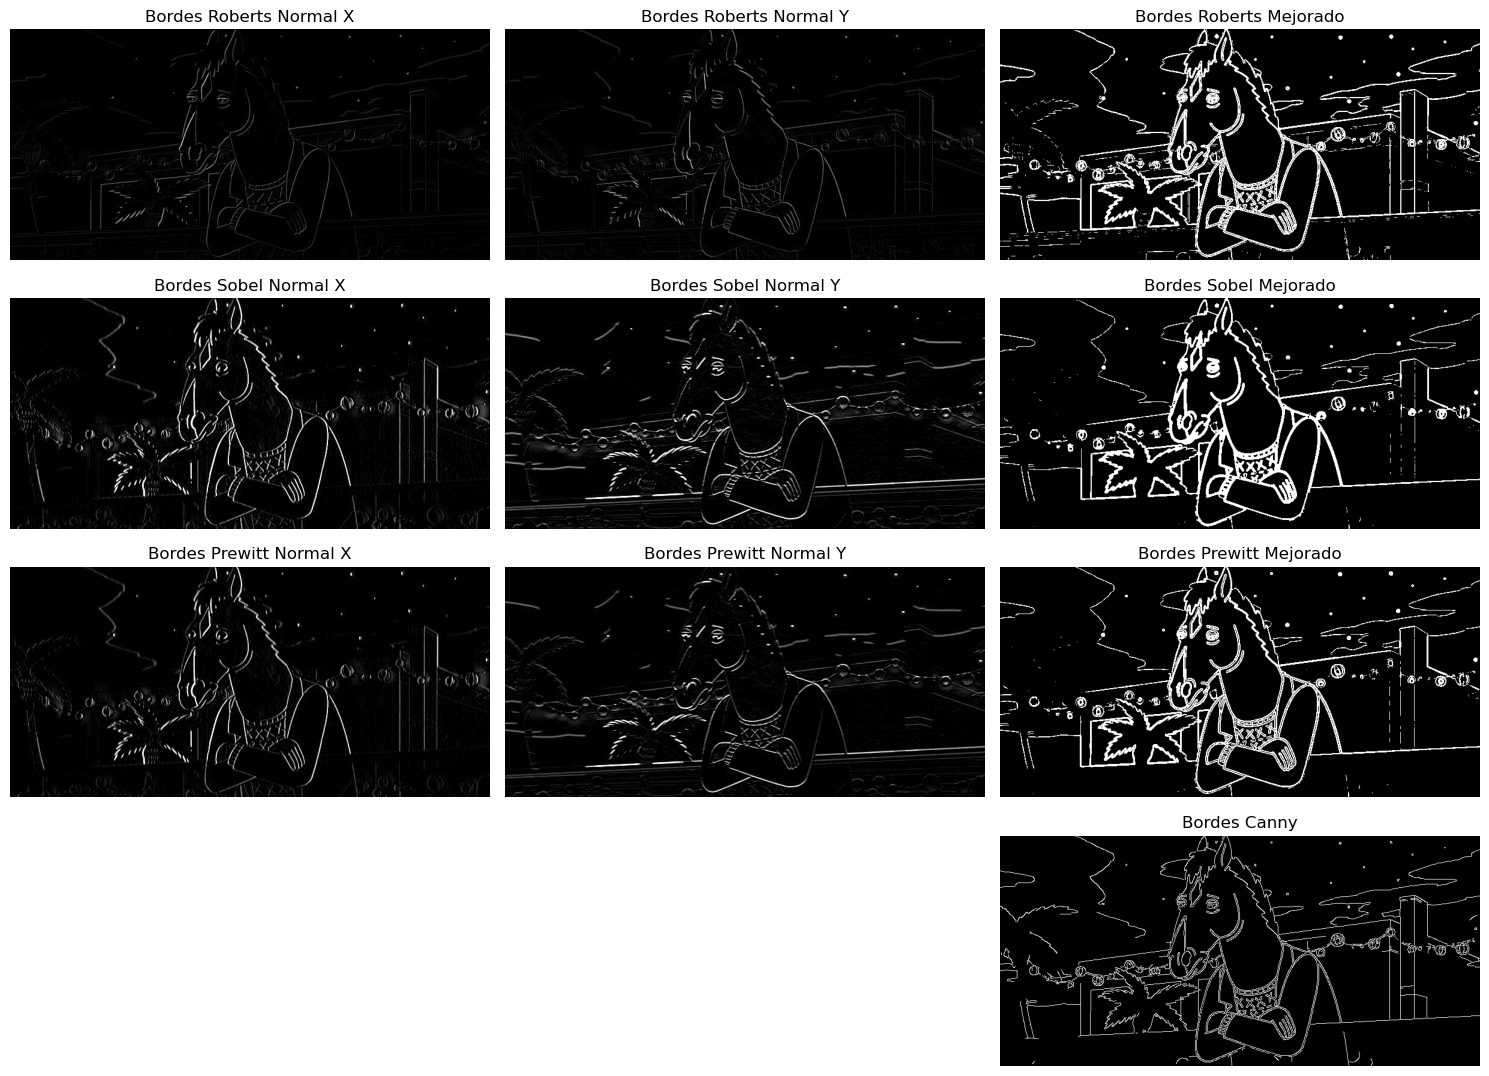

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

kernel_roberts_x = np.array([[-1, 0],
                             [0, 1]])
kernel_roberts_y = np.array([[0, -1],
                             [1, 0]])
def roberts_normal(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  roberts_x = cv2.filter2D(img_gray, -1, kernel_roberts_x)
  roberts_y = cv2.filter2D(img_gray, -1, kernel_roberts_y)
  
  return roberts_x, roberts_y

def roberts_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)

  kernel_x = 2 * kernel_roberts_x
  kernel_y = 2 * kernel_roberts_y

  img_bordes_roberts_x = cv2.filter2D(suavizado, cv2.CV_16S, kernel_x)
  img_bordes_roberts_y = cv2.filter2D(suavizado, cv2.CV_16S, kernel_y)

  roberts = cv2.addWeighted(np.abs(img_bordes_roberts_x), 0.7, np.abs(img_bordes_roberts_y), 0.7, 0)
  _, bordes = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY)
  return bordes

def sobel_normal(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  kernel_sobel_x = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])
  kernel_sobel_y = np.array([[1, 2, 1],
                              [0, 0, 0],
                              [-1, -2, -1]])

  roberts_x = cv2.filter2D(img_gray, -1, kernel_sobel_x)
  roberts_y = cv2.filter2D(img_gray, -1, kernel_sobel_y)
  
  return roberts_x, roberts_y

def sobel_mejorado(img, tam_kernel=3, umbral=30):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  sobel_x = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel)
  sobel_y = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel)
  
  # magnitud = cv2.addWeighted(np.abs(sobel_x), 0.7, np.abs(sobel_y), 0.7, 0)
  magnitud = np.sqrt(sobel_x**2 + sobel_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY) # Agregariamos otsu
  _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Agregariamos otsu

  # Unir bordes rotos
  kernel_morf = np.ones((2, 2), np.uint8)
  bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
  
  return bordes

def prewitt_normal(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  kernel_prewitt_x = np.array([[1, 0, -1],
                                [1, 0, -1],
                                [1, 0, -1]])
  kernel_prewitt_y = np.array([[1, 1, 1],
                                  [0, 0, 0],
                                  [-1, -1, -1]])
  
  prewitt_x = cv2.filter2D(img_gray, -1, kernel_prewitt_x)
  prewitt_y = cv2.filter2D(img_gray, -1, kernel_prewitt_y)
  
  return prewitt_x, prewitt_y

def prewitt_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  kernel_prewitt_x = 3 * np.array([[1, 0, -1],
                                  [1, 0, -1],
                                  [1, 0, -1]], dtype=np.float32)
  kernel_prewitt_y = 3 * np.array([[1, 1, 1],
                                  [0, 0, 0],
                                  [-1, -1, -1]], dtype=np.float32)
  
  prewitt_x = cv2.filter2D(suavizado, cv2.CV_64F, kernel_prewitt_x)
  prewitt_y = cv2.filter2D(suavizado, cv2.CV_64F, kernel_prewitt_y)
  
  magnitud = np.sqrt(prewitt_x**2 + prewitt_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY)
  _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  return bordes

img = cv2.imread('./images/img1.jpeg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Roberts
img_roberts_x, img_roberts_y = roberts_normal(img)
img_roberts_mejorado = roberts_mejorado(img)

# Sobel
img_sobel_x, img_sobel_y = sobel_normal(img)
img_sobel_mejorado = sobel_mejorado(img)

# Prewitt
img_prewitt_x, img_prewitt_y = prewitt_normal(img)
img_prewitt_mejorado = prewitt_mejorado(img)

# Canny
img_canny = cv2.Canny(img_gray, 100, 200)

# Mostrar resultados
plt.figure(figsize=(15, 11))

plt.subplot(4, 3, 1)
plt.imshow(img_roberts_x, cmap='gray')
plt.title('Bordes Roberts Normal X')
plt.axis('off')

plt.subplot(4, 3, 2)
plt.imshow(img_roberts_y, cmap='gray')
plt.title('Bordes Roberts Normal Y')
plt.axis('off')

plt.subplot(4, 3, 3)
plt.imshow(img_roberts_mejorado, cmap='gray')
plt.title('Bordes Roberts Mejorado')
plt.axis('off')

plt.subplot(4, 3, 4)
plt.imshow(img_sobel_x, cmap='gray')
plt.title('Bordes Sobel Normal X')
plt.axis('off')

plt.subplot(4, 3, 5)
plt.imshow(img_sobel_y, cmap='gray')
plt.title('Bordes Sobel Normal Y')
plt.axis('off')

plt.subplot(4, 3, 6)
plt.imshow(img_sobel_mejorado, cmap='gray')
plt.title('Bordes Sobel Mejorado')
plt.axis('off')

plt.subplot(4, 3, 7)
plt.imshow(img_prewitt_x, cmap='gray')
plt.title('Bordes Prewitt Normal X')
plt.axis('off')

plt.subplot(4, 3, 8)
plt.imshow(img_prewitt_y, cmap='gray')
plt.title('Bordes Prewitt Normal Y')
plt.axis('off')

plt.subplot(4, 3, 9)
plt.imshow(img_prewitt_mejorado, cmap='gray')
plt.title('Bordes Prewitt Mejorado')
plt.axis('off')

plt.subplot(4, 3, 12)
plt.imshow(img_canny, cmap='gray')
plt.title('Bordes Canny')
plt.axis('off')

plt.tight_layout()
plt.show()